# Machine Learning: Assignment 4
## Regression methods (max. 10p)

In [156]:
# Write Your information in here
student_name = 'Jaka Cosic Hämäläinen'
student_email = "aa6111@student.jamk.fi"

## Assignment 4.1: Preprocess the data (2 p)
### Topic: Productivity of textile workers

1. Explore and download the data from [https://archive.ics.uci.edu/ml/datasets/Productivity+Prediction+of+Garment+Employees#](https://archive.ics.uci.edu/ml/datasets/Productivity+Prediction+of+Garment+Employees#). Load the data into the DataFrame.

2. Remove background variables from the analyzed data.

3. Decide what to do with the missing values.

4. Normalize the data.

5. Additionally, create a new class variable with a value of 0 if the productivity is less than 0.5 and with a value of 1 if the productivity is above 0.5. Store this in the df variable as column `class`. That will be used in classification assignment (4.3).

In [157]:
# TODO: Write your code in this cell.

# TODO: Data Preprocessing
import pandas as pd
df = pd.read_csv("data/garments_worker_productivity.csv")

df = df.drop(columns=['date', 'day', 'team'])

# Check for missing values
# wip has 506 missing values and I decided to remove it from the dataset
df.drop(columns=['wip'], inplace=True)
# print(df.isnull().sum())

# Data normalization
from sklearn.preprocessing import MinMaxScaler

df = pd.get_dummies(df, columns=['quarter', 'department'], drop_first=False)

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
scaler = MinMaxScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# Create a new class variable
def class_productivity(productivity):
    if productivity >= 0.5:
        return 1
    else:
        return 0

df['class'] = df['actual_productivity'].apply(class_productivity)
#print(df[['actual_productivity', 'class']].head())



In [158]:
# Answers to the assignment. Note! Do not edit this cell, just run it after you complete the assignment.
# Save the DataFrame to the df variable and the training data.
print(f'Columns: {df.columns}')
print(f'First row by position: {df.iloc[0]}')

Columns: Index(['targeted_productivity', 'smv', 'over_time', 'incentive', 'idle_time',
       'idle_men', 'no_of_style_change', 'no_of_workers',
       'actual_productivity', 'quarter_Quarter1', 'quarter_Quarter2',
       'quarter_Quarter3', 'quarter_Quarter4', 'quarter_Quarter5',
       'department_finishing', 'department_finishing ', 'department_sweing',
       'class'],
      dtype='object')
First row by position: targeted_productivity         1.0
smv                      0.450252
over_time                0.273148
incentive                0.027222
idle_time                     0.0
idle_men                      0.0
no_of_style_change            0.0
no_of_workers            0.655172
actual_productivity      0.797332
quarter_Quarter1             True
quarter_Quarter2            False
quarter_Quarter3            False
quarter_Quarter4            False
quarter_Quarter5            False
department_finishing        False
department_finishing        False
department_sweing            True
c

## Assignment 4.2: Regression using a Linear Regression model (2 p)

1. Split the data into training (67%) and testing data (33%), also saving the class variables as their own vectors (`X_train`, `y_train`, `X_test`, `y_test`). Use random seed `2150`.

Tip: don't put the columns `actual_productivity` or `class` in the input variables (features).

2. Use the [functions](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.ensemble) from `ensemble` module
of the `scikit-learn` library and create a regression model using a linear regressor. So you try to predict the `actual_productivity` variable.

Use random seed `2100`.

3. Predict the `actual_productivity` of the test dataset. Record the explained variance `exp_var` and
the maximum error `max_err` using the tools in the `metrics` module of the library.

In [159]:
from sklearn.model_selection import train_test_split

# TODO: Write your code in this cell
X_test = X_train = exp_var = max_err = None

# TODO: Split the data into training (67%) and testing data (33%)

X = df.drop(columns=['actual_productivity', 'class'])
y = df['actual_productivity']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=2150)

In [160]:
# TODO: Create and test Linear regression model

from sklearn.linear_model import LinearRegression
from sklearn.metrics import explained_variance_score, max_error

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

exp_var = explained_variance_score(y_test, y_pred)
max_err = max_error(y_test, y_pred)

weights = y_test
exp_var_2 = explained_variance_score(y_test, y_pred, sample_weight=weights)


In [161]:
# Answers to the assignment. Note! Do not edit this cell, just run it after you complete the assignment.
# Save responses in exp_var and max_err variables.
# print(f'Test length: {len(X_test)}')
# print(f'Train length: {len(X_train)}')
# print(f'Train columns: {X_train.columns}')
# print(f'Train columns length: {len(X_train.columns)}')
# print(f'Predict 5 items: {y_pred[:5]} ... {y_pred[-5:]}')

# exp_var = max_err = exp_var_2 = None

print(f'Explained variance: {exp_var}')
print(f'Maximum error: {max_err}')
print(f'Explained variance (Weighted): {exp_var_2}')

Explained variance: 0.2610327783435954
Maximum error: 0.6186655833888097
Explained variance (Weighted): 0.22090494109428904


**Explained variance** refers to the variance in the response variable in a model that can be explained by the predictor variable(s) in the model.
The higher the explained variance of a model, the more the model is able to explain the variation in the data.

Calculate and analyze the explained variance for the assignment.

In [162]:
# TODO: Explained variance

weights = df.loc[X_test.index, 'class']
exp_var_weighted = explained_variance_score(y_test, y_pred, sample_weight=weights)
# exp_var_weighted = None
print(f'Explained variance (Weighted): {exp_var_2}')
print(f'Explained variance (Weighted): {exp_var_weighted}')

Explained variance (Weighted): 0.22090494109428904
Explained variance (Weighted): 0.04926992482548098


## Assignment 4.3: Classification using Random Forest (2 p)

1. Create training and testing data. Use random seed `2150`. Note that the `class` variable is now predicted.

2. Use the [functions](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.ensemble) from `ensemble` module
of the `scikit-learn` library and create a classification model using a random forest. Use random seed `2100`. So let's try to predict the class variable `class`.

3. Predict `class` from the test data. Generate the accuracy report `cr` and the confusion matrix `cm` using the tools in the `metrics` module of the library.

In [163]:
# TODO: Write your code in this cell
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

X_test = X_train = cr = cm = None

X = df.drop(columns=['class'])
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=2150)

model = RandomForestClassifier(random_state=2100)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

cr = classification_report(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)


In [164]:
# Answers to the assignment. Note! Do not edit this cell, just run it after you complete the assignment.
# The results are in cm and cr variables.
print(f'Test length: {len(X_test)}')
print(f'Train length: {len(X_train)}')
print(cr)
print(cm)

Test length: 396
Train length: 801
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       127
           1       1.00      1.00      1.00       269

    accuracy                           1.00       396
   macro avg       1.00      1.00      1.00       396
weighted avg       1.00      1.00      1.00       396

[[127   0]
 [  0 269]]


Show the importance of the features when using the **Random Forest Classifier** method.

In [165]:
# TODO: the importance of features
feature_importances = None
feature_importances = model.feature_importances_

feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print(feature_importance_df)

                  Feature  Importance
8     actual_productivity    0.697992
0   targeted_productivity    0.088284
3               incentive    0.063765
7           no_of_workers    0.040659
1                     smv    0.039019
2               over_time    0.025907
16      department_sweing    0.009641
6      no_of_style_change    0.009119
12       quarter_Quarter4    0.004416
5                idle_men    0.003604
9        quarter_Quarter1    0.003500
10       quarter_Quarter2    0.003090
11       quarter_Quarter3    0.002945
14   department_finishing    0.002807
15  department_finishing     0.002388
13       quarter_Quarter5    0.001540
4               idle_time    0.001325


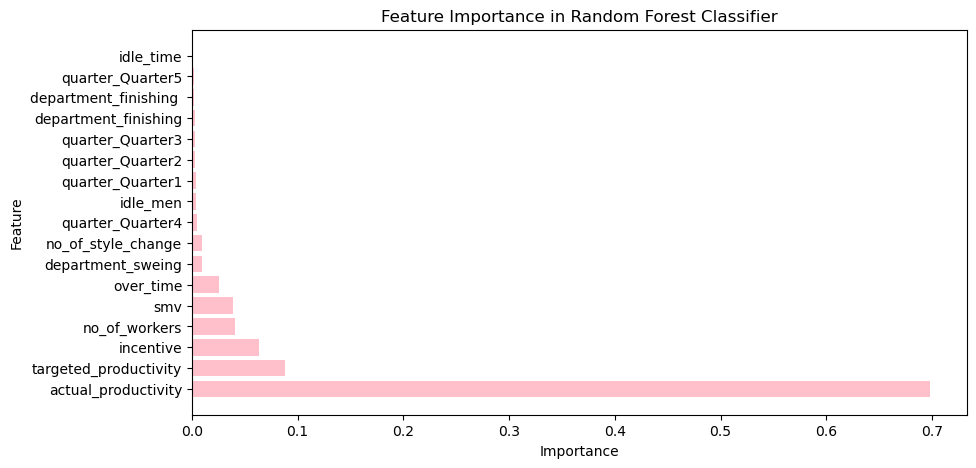

In [166]:
# TODO: Visualize the importance of features

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='pink')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance in Random Forest Classifier')
plt.show()

## Assignment 4.4: Regression using Random Forest Regressor (2 p)

Repeat same than **assignment 4.2** but now using a **Random Forest Regression** method.

Also calculate the *explained variance* and *maximum error*.

In [167]:
# TODO: Write your code in this cell
# TODO: use Random Forest Regressor

from sklearn.ensemble import RandomForestRegressor

X = df.drop(columns=['actual_productivity'])
y = df['actual_productivity']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=2150)

model = RandomForestRegressor(random_state=2100)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

exp_var = explained_variance_score(y_test, y_pred)
max_err = max_error(y_test, y_pred)

weights = y_test
exp_var_2 = explained_variance_score(y_test, y_pred, sample_weight=weights)

In [168]:
# Answers to the assignment. Note! Do not edit this cell, just run it after you complete the assignment.
# Save responses in exp_var and max_err and exp_var_2 variables.

print(f'Explained variance: {exp_var}')
print(f'Maximum error: {max_err}')

Explained variance: 0.8328075444219004
Maximum error: 0.4120286431139659


**Explained variance** refers to the variance in the response variable in a model that can be explained by the predictor variable(s) in the model.
The higher the explained variance of a model, the more the model is able to explain the variation in the data.

Calculate and analyze the explained variance for the assignment.

In [169]:
# TODO: Explained variance

weights = df.loc[X_test.index, 'class']
exp_var_weighted = explained_variance_score(y_test, y_pred, sample_weight=weights)

print(f'Explained variance (Weighted): {exp_var_2}')
print(f'Explained variance (Weighted): {exp_var_weighted}')

Explained variance (Weighted): 0.8049563266407855
Explained variance (Weighted): 0.6507931100382958


Show the **importance of the features** when using **Random Forest Regressor** method.

In [170]:
# TODO: the importance of features with Random Forest Regressor

feature_importances = model.feature_importances_

feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print(feature_importance_df)

                  Feature  Importance
16                  class    0.670386
3               incentive    0.069531
1                     smv    0.066058
0   targeted_productivity    0.056088
2               over_time    0.045716
7           no_of_workers    0.034325
9        quarter_Quarter2    0.007891
10       quarter_Quarter3    0.007540
8        quarter_Quarter1    0.007234
11       quarter_Quarter4    0.007091
15      department_sweing    0.006172
13   department_finishing    0.006115
14  department_finishing     0.005484
12       quarter_Quarter5    0.002876
5                idle_men    0.002779
6      no_of_style_change    0.002507
4               idle_time    0.002206


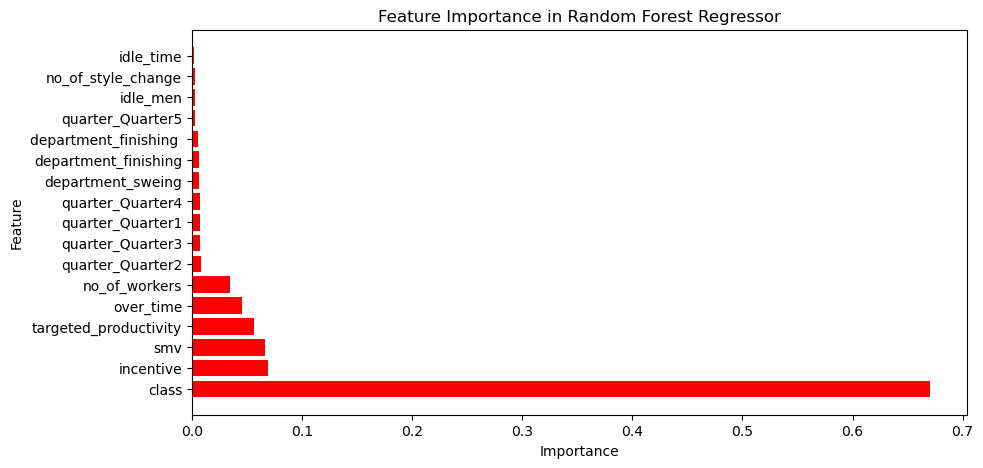

In [171]:
# TODO: Visualize the importance of features

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='red')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance in Random Forest Regressor')
plt.show()


## Assignment 4.5: Analysis of results (2 p)

Let's do a result analysis where you verbally compare the regression results obtained in the assignments 4.2 and 4.4.
* **4.2** (Linear regression) and
* **4.4** (Random Forest regression).

You can use **tables** or **figures** to present results in addition to verbal explanation and analysis.

Comparison of Different Regression Models:

* Compare the regression results of Random Forest and Linear Regression models.
* Is there others good regression methods to apply with this dataset?

<font color="red">PLEASE WRITE YOUR EXPLANATION HERE.</font>



Random Forest Regression generally gave better outputs than Linear Regression. Explained variance is higher for Random Forest which means that the model explains the variance in productivity much better than Linear Regression. In other words, the dataset's patterns, which can be non-linear, are easier for Random Forest to capture than it is for the linear model. Maximum Error differences show that Random Forest provides better predictions compared to Linear Regression. This is because it is more likely for liner Regression to be affected by outliers in the data. Weighted Explained Variance was calculated with y_pred and with class variables, and both outcomes were higher for Random Forest Regression model which implies that it provides better predictions when applying weight. This difference is most significant when comparing results after applying class as a weight.
Another possible regression method that could be applied would be Gradient Boosting Regression. As it is described in the class material as an "ensemble method that combines multiple different regression models to make predictions". I can work iteratively by improving on weak models and possibly be more effective than Random Forest Regression. 

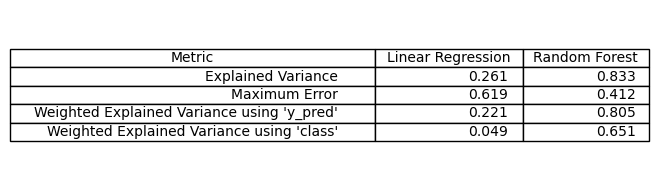

In [189]:
import matplotlib.pyplot as plt

models = ["Linear Regression", "Random Forest Regression"]
explained_variance = [0.2610327783435954, 0.8328075444219004]
max_error = [0.6186655833888097, 0.4120286431139659] 
weighted_explained_variance = [0.22090494109428904, 0.8049563266407855]
weighted_explained_variance_class = [0.04926992482548098, 0.6507931100382958]

fig, ax = plt.subplots(figsize=(6, 2))

data = [
    ["Explained Variance", f"{explained_variance[0]:.3f}", f"{explained_variance[1]:.3f}"],
    ["Maximum Error", f"{max_error[0]:.3f}", f"{max_error[1]:.3f}"],
    ["Weighted Explained Variance using 'y_pred'", f"{weighted_explained_variance[0]:.3f}", f"{weighted_explained_variance[1]:.3f}"],
    ["Weighted Explained Variance using 'class'", f"{weighted_explained_variance_class[0]:.3f}", f"{weighted_explained_variance_class[1]:.3f}"]
]

table = ax.table(cellText=data, colLabels=["Metric", "Linear Regression", "Random Forest"], loc='center')
table.auto_set_font_size(False)
table.auto_set_column_width([0, 1, 2])
fig.patch.set_visible(False)
ax.axis("off") 
ax.axis('tight')
fig.tight_layout()
plt.show()